In [1]:
# {Always Check Version Of The Libraries}

# { Python Version }
import sys
print('Python: {}'.format(sys.version))
# scipy
import scipy
print('scipy: {}'.format(scipy.__version__))
# numpy
import numpy
print('numpy: {}'.format(numpy.__version__))
# matplotlib
import matplotlib
print('matplotlib: {}'.format(matplotlib.__version__))
# pandas
import pandas
print('pandas: {}'.format(pandas.__version__))
# scikit-learn
import sklearn
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
scipy: 1.16.3
numpy: 2.4.0
matplotlib: 3.10.8
pandas: 2.3.3
sklearn: 1.8.0


In [2]:
# { Load The Libraries }
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [3]:
# { Load The Dataset }

data = pandas.read_csv("iris.csv")

In [4]:
# { Using The URL }
# url = "https://raw.githubusercontent.com/sekwatinukere/Datasets/master/iris.csv"
# names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
# dataset = read_csv(url, names=names)

In [5]:
print(data.shape)

(150, 6)


In [6]:
print(data.head(20))

    Id  SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0    1          5.1         3.5          1.4         0.2  Iris-setosa
1    2          4.9         3.0          1.4         0.2  Iris-setosa
2    3          4.7         3.2          1.3         0.2  Iris-setosa
3    4          4.6         3.1          1.5         0.2  Iris-setosa
4    5          5.0         3.6          1.4         0.2  Iris-setosa
5    6          5.4         3.9          1.7         0.4  Iris-setosa
6    7          4.6         3.4          1.4         0.3  Iris-setosa
7    8          5.0         3.4          1.5         0.2  Iris-setosa
8    9          4.4         2.9          1.4         0.2  Iris-setosa
9   10          4.9         3.1          1.5         0.1  Iris-setosa
10  11          5.4         3.7          1.5         0.2  Iris-setosa
11  12          4.8         3.4          1.6         0.2  Iris-setosa
12  13          4.8         3.0          1.4         0.1  Iris-setosa
13  14          4.3 

In [7]:
print(data.describe())

               Id  SepalLength  SepalWidth  PetalLength  PetalWidth
count  150.000000   150.000000  150.000000   150.000000  150.000000
mean    75.500000     5.843333    3.054000     3.758667    1.198667
std     43.445368     0.828066    0.433594     1.764420    0.763161
min      1.000000     4.300000    2.000000     1.000000    0.100000
25%     38.250000     5.100000    2.800000     1.600000    0.300000
50%     75.500000     5.800000    3.000000     4.350000    1.300000
75%    112.750000     6.400000    3.300000     5.100000    1.800000
max    150.000000     7.900000    4.400000     6.900000    2.500000


In [8]:
# { Class Distribution }
print(data.groupby("Species").size())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


In [9]:
data = data.dropna()

In [10]:
data = data.drop_duplicates()

In [11]:
(data.isnull().sum() / (len(data)))*100

Id             0.0
SepalLength    0.0
SepalWidth     0.0
PetalLength    0.0
PetalWidth     0.0
Species        0.0
dtype: float64

In [12]:
# { Dropping the Id Column }
data = data.drop("Id", axis=1)

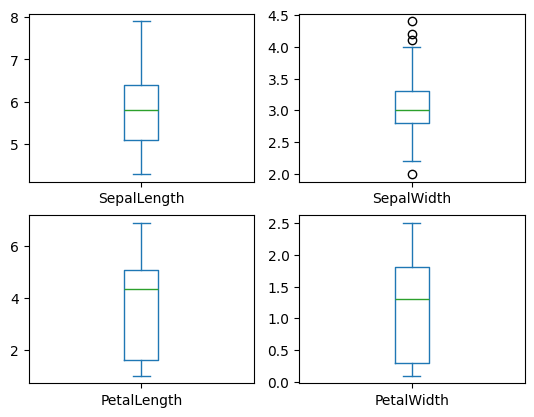

In [13]:
data.plot(kind="box", subplots=True, layout=(2,2), sharex=False, sharey=False,)
plt.show()

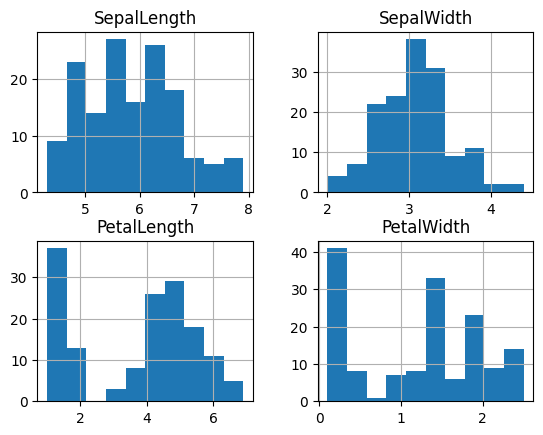

In [14]:
data.hist()
plt.show()

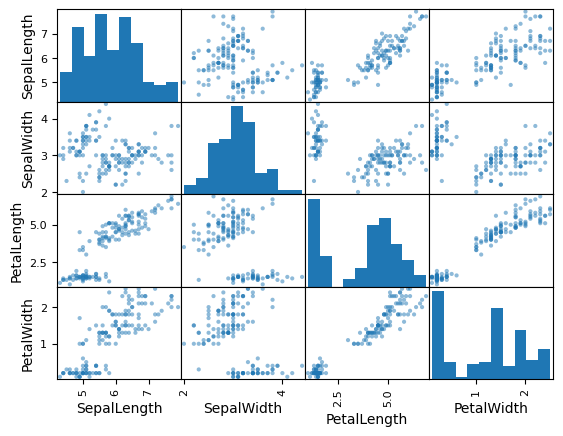

In [15]:
scatter_matrix(data)
plt.show()

In [16]:
# { Splitting-out validation data }
array = data.values
X = array[:,0:4]
Y = array[:,4]
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=0.20, random_state=1)

In [23]:
# { Spot Check Algos }

models = []
models.append(('LR', LogisticRegression(solver='liblinear')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))
# evaluate each model in turn
results = []
names = []
for name, model in models:
	kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
	cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
	results.append(cv_results)
	names.append(name)
	print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1208, in fit
    raise ValueError(
ValueError: The 'liblinear' solver does not support multiclass classi

In [20]:
-- Connect to wifi source to complete

SyntaxError: invalid syntax (851693125.py, line 1)